# Iris Flower Classification

<img src="https://storage.googleapis.com/kaggle-media/learn/images/RcxYYBA.png">

### Context

The Iris flower dataset consists of three species: setosa, versicolor, and virginica. These species can be distinguished based on their measurements. Now, imagine that you have the measurements of Iris flowers categorized by their respective species. Your objective is to train a machine learning model that can learn from these measurements and accurately classify the Iris flowers into their respective species.

### Project Objective

Use the Iris dataset to develop a model that can classify iris flowers into different species based on their sepal and petal measurements. This dataset is widely used for introductory classification tasks.

In [ ]:
# Import the kagglehub library to allow downloading datasets directly from Kaggle
import kagglehub
# Download the dataset using its Kaggle identifier and save its local file path to a variable
arshid_iris_flower_dataset_path = kagglehub.dataset_download('arshid/iris-flower-dataset')
# Print a confirmation message to let us know the download was successful
print('Data source import complete.')

100%|██████████| 0.99k/0.99k [00:00<00:00, 218kB/s]

Extracting files...
Data source import complete.


### Explanation
**What does this code do?**
This cell downloads the Iris Flower dataset straight from Kaggle servers to the Google Colab environment and stores the location where it was saved.

**Why is it important for the project?**
This is the **Dataset Import** phase. Every machine learning project requires data to learn from. This step ensures we have the raw data necessary to build our models.

In [ ]:
# Import pandas and give it the alias 'pd', used for manipulating tabular data (like Excel spreadsheets)
import pandas as pd
# Import numpy and give it the alias 'np', used for complex mathematical operations and arrays
import numpy as np
# Import matplotlib.pyplot as 'plt', the foundational library for creating charts and graphs
import matplotlib.pyplot as plt
# Import seaborn as 'sns', an advanced data visualization library built on top of matplotlib
import seaborn as sns
# Import the warnings library to manage system warnings
import warnings
# Instruct Python to ignore (hide) non-critical warning messages to keep our notebook clean
warnings.filterwarnings('ignore')

### Explanation
**What does this code do?**
It imports all the standard Python libraries needed for data analysis, manipulation, and visualization. It also hides messy warning messages.

**Why is it important for the project?**
Python relies on external libraries to perform specialized tasks. `pandas` and `seaborn` are essential tools we will use to explore and visualize the dataset.

In [ ]:
# Use pandas' read_csv function to read the downloaded CSV file into a DataFrame named 'iris'
# We use an f-string (f'{...}') to dynamically insert the folder path we downloaded earlier
iris = pd.read_csv(f'{arshid_iris_flower_dataset_path}/IRIS.csv')

### Explanation
**What does this code do?**
It opens the CSV (Comma Separated Values) file containing our data and loads it into a structured format called a Pandas DataFrame, which looks like a table.

**Why is it important for the project?**
Loading the file into a DataFrame is what actually allows us to interact with the data in Python, look at rows/columns, and eventually feed it into machine learning models.

In [ ]:
# Display the first 5 rows of the 'iris' DataFrame to get a quick look at the data structure
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Explanation
**What does this code do?**
It outputs the top 5 rows of our table so we can visually inspect the columns (like sepal_length, species, etc.) and the values inside them.

**Why is it important for the project?**
This starts the **Exploration** phase. Visually checking the data ensures it loaded correctly and helps us understand exactly what features we are working with.

In [ ]:
# Access the 'shape' attribute of the DataFrame to see its dimensions (rows, columns)
iris.shape

(150, 5)

### Explanation
**What does this code do?**
It returns a tuple of two numbers representing the total number of rows and total number of columns in the dataset.

**Why is it important for the project?**
Knowing the size of the dataset helps us understand the scale of our problem. (For Iris, it's typically 150 rows and 5 columns).

In [ ]:
# Call the 'describe' method to generate descriptive statistics for all numerical columns
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Explanation
**What does this code do?**
It calculates and displays statistical summaries like the mean, standard deviation, minimum, and maximum values for all the flower measurements.

**Why is it important for the project?**
This helps us spot any immediate anomalies (like negative lengths) and understand the general range of sizes for the sepals and petals.

In [ ]:
# Group the data by the 'species' column and calculate the average (mean) for each group's measurements
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


### Explanation
**What does this code do?**
It splits the table into three groups (setosa, versicolor, virginica) and calculates the average length and width of the petals and sepals for each specific flower type.

**Why is it important for the project?**
This is a powerful **Exploration** technique. It reveals immediately that different species have distinct average sizes (e.g., setosa has much smaller petals), hinting that a machine learning model will be able to distinguish them easily.

## Data Visualization

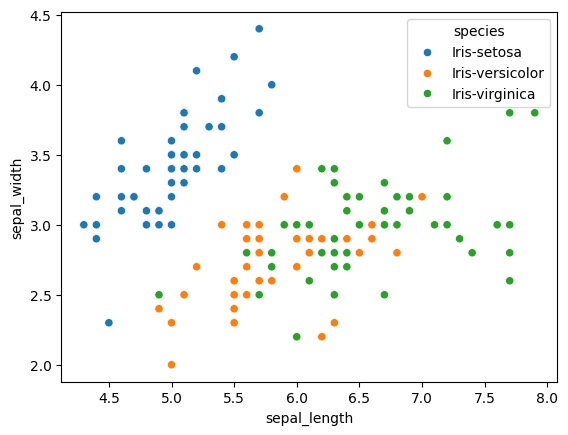

In [ ]:
# Create a scatterplot mapping sepal_length to the X-axis and sepal_width to the Y-axis
# Color-code the data points based on their 'species' using the 'hue' parameter
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=iris)
# Render and display the plot
plt.show()

### Explanation
**What does this code do?**
It generates a dot-based graph (scatterplot) showing the relationship between sepal length and width. The dots are colored differently depending on which species of Iris they belong to.

**Why is it important for the project?**
This **Visualization** step lets us see with our own eyes how the data points cluster. We can see if certain species group together in specific areas of the graph.

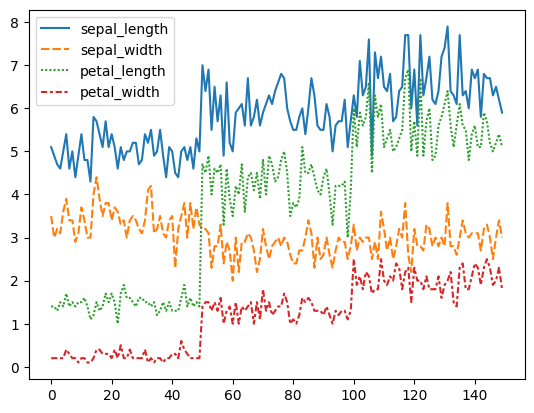

In [ ]:
# Temporarily drop the 'species' column and plot the remaining numerical data as continuous lines
sns.lineplot(data=iris.drop(['species'], axis=1))
# Render and display the plot
plt.show()

### Explanation
**What does this code do?**
It draws line charts for all the numerical features (sepal/petal length/width) across all rows in the dataset.

**Why is it important for the project?**
While line plots aren't usually the best for independent measurements like flowers, it does give a quick visual representation of the fluctuation of values across the whole dataset.

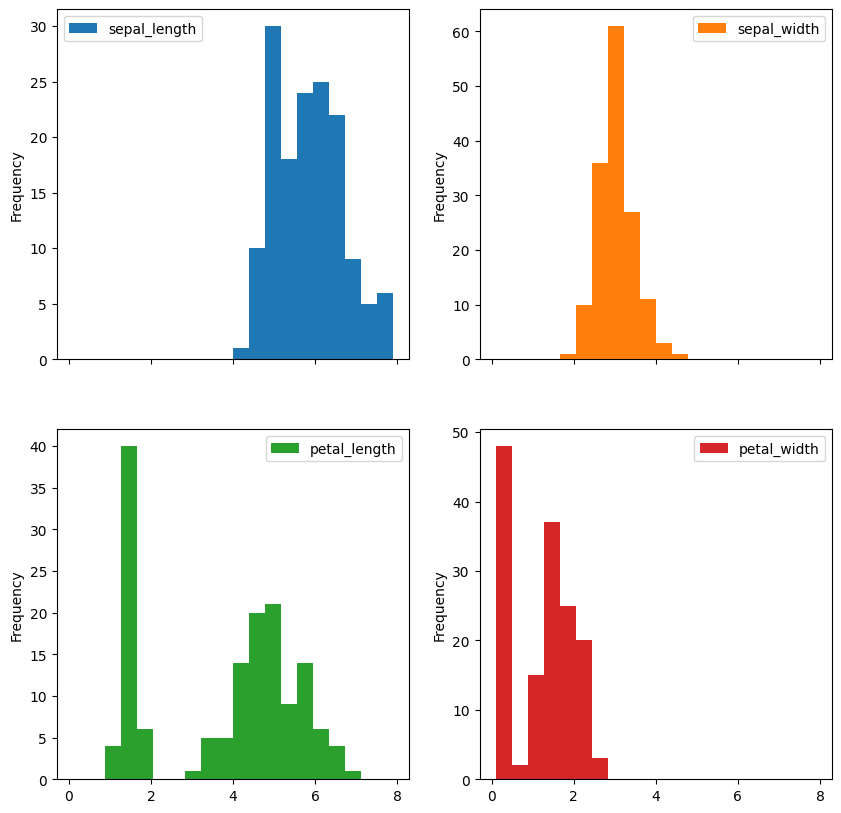

In [ ]:
# Create multiple histograms (subplots=True) arranged in a 2x2 grid (layout=(2,2))
# Set the chart size to 10x10 inches and divide the data into 20 bins (bars)
iris.plot.hist(subplots=True, layout=(2,2), figsize=(10, 10), bins=20)
# Render and display the plots
plt.show()

### Explanation
**What does this code do?**
It creates four separate bar charts (histograms) showing the frequency distribution for sepal length, sepal width, petal length, and petal width.

**Why is it important for the project?**
Histograms show us the shape of the data. We can see if a measurement follows a normal distribution (bell curve) or if it's heavily skewed, which can affect how some machine learning models perform.

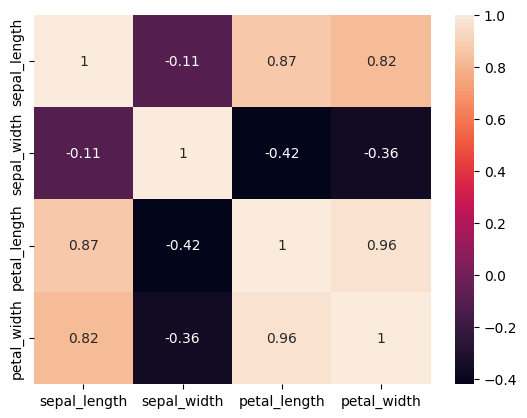

In [ ]:
# Calculate the mathematical correlation between numerical columns (dropping the text 'species' column)
# Then, pass those correlation numbers into a heatmap, adding the numbers to the squares (annot=True)
sns.heatmap(iris.drop('species', axis=1).corr(), annot=True)
# Render and display the plot
plt.show()

### Explanation
**What does this code do?**
It generates a color-coded grid (heatmap) showing the correlation coefficient between every pair of measurements. A value near 1 means strong positive correlation.

**Why is it important for the project?**
This is a crucial **Visualization**. It tells us which features are highly related. For example, petal length and petal width are usually highly correlated, meaning if a flower has a long petal, it likely has a wide petal too.

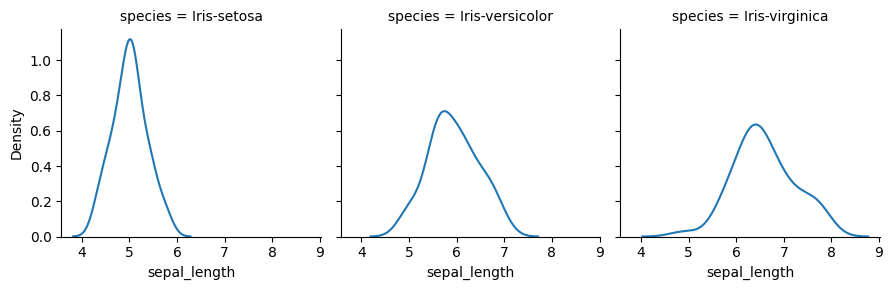

In [ ]:
# Create a grid of plots, creating one column for each unique value in the 'species' column
g = sns.FacetGrid(iris, col='species')
# Map a Kernel Density Estimate (KDE) plot (smooth curve) for 'sepal_length' onto each grid item
g = g.map(sns.kdeplot, 'sepal_length')

### Explanation
**What does this code do?**
It creates three side-by-side smooth distribution curves showing the concentration of 'sepal_length' for each individual species.

**Why is it important for the project?**
It allows us to isolate a single feature (sepal length) and see exactly how it differs across the three target classes we want to predict.

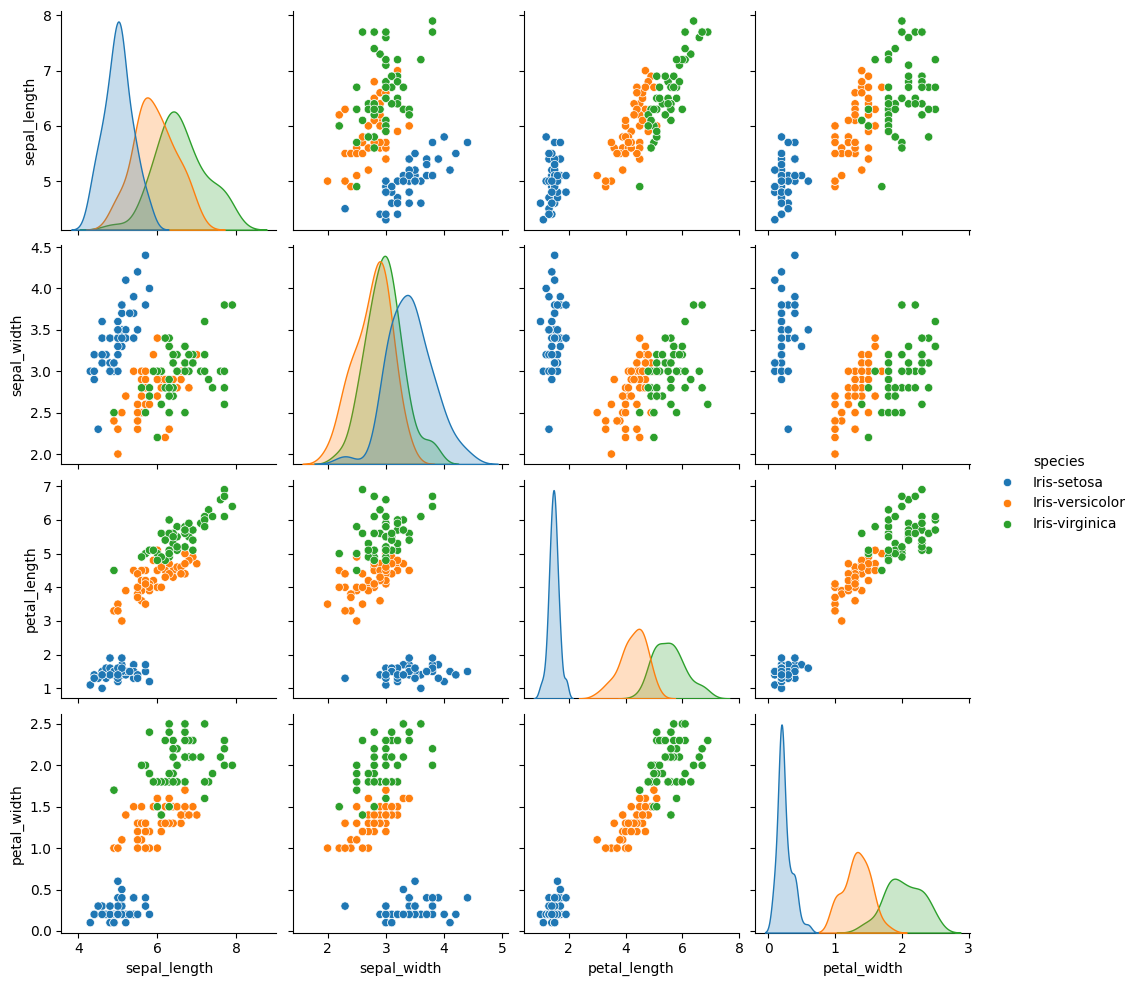

In [ ]:
# Generate a matrix of scatterplots for every possible pairing of numerical columns
sns.pairplot(iris, hue='species') # Added hue='species' to make the pairplot much more useful!


### Explanation
**What does this code do?**
It draws a massive grid that pairs every feature against every other feature in a scatterplot, coloring the dots by species.

**Why is it important for the project?**
This is perhaps the most powerful exploratory tool. In one glance, you can see which combination of features best separates the different flower species, revealing the boundaries our model will need to learn.

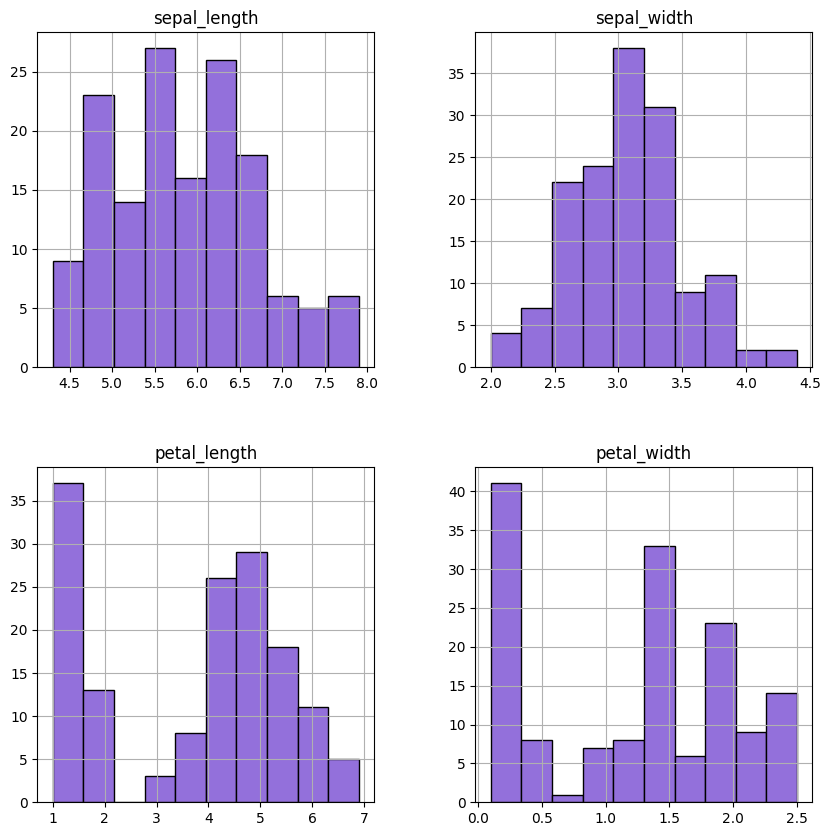

In [ ]:
# Generate histograms directly from the DataFrame, styling the color to 'mediumpurple' and outlining the bars
iris.hist(color='mediumpurple', edgecolor='black', figsize=(10,10))
# Render and display the plots
plt.show()

### Explanation
**What does this code do?**
It provides an alternative, stylized way to view the same histograms we generated earlier, adding better colors and clear black borders to the bars.

**Why is it important for the project?**
Good visualization aesthetics make data easier to read and interpret, especially when presenting your findings to others.

In [ ]:
# Drop the text 'species' column, calculate correlations, and apply a cool-to-warm background color gradient
iris.drop('species', axis=1).corr().style.background_gradient(cmap='coolwarm')

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


### Explanation
**What does this code do?**
It displays the correlation matrix as a stylized Pandas table where high values are colored warm (red) and low values are colored cool (blue).

**Why is it important for the project?**
It provides a cleaner, purely numerical alternative to the Seaborn heatmap we generated earlier.

## Machine Learning

In [ ]:
# Import train_test_split to randomly split our data into training and testing portions
from sklearn.model_selection import train_test_split
# Import the metrics module to calculate how well our models perform
from sklearn import metrics
# Specifically import accuracy_score for checking the percentage of correct predictions
from sklearn.metrics import accuracy_score
# Import classification_report for a detailed breakdown of model performance
from sklearn.metrics import classification_report

### Explanation
**What does this code do?**
It imports necessary tools from `scikit-learn` (sklearn), the most popular machine learning library in Python.

**Why is it important for the project?**
These specific tools allow us to properly structure our experiment (splitting data) and evaluate our results (accuracy scores) in the upcoming **Model Training** and **Evaluation** phases.

In [ ]:
# Create our 'X' variable (Features) by dropping the target 'species' column. This holds the measurements.
x = iris.drop('species', axis=1)
# Create our 'Y' variable (Labels) which only contains the 'species' column. This is what we want to predict.
y = iris.species

# Split the features and labels: 60% of data goes to training, 40% goes to testing.
# random_state=5 ensures the random split is exactly the same every time we run the code.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=5)

### Explanation
**What does this code do?**
It separates the inputs (measurements) from the outputs (flower names), then slices the whole dataset into two parts: a 'train' set and a 'test' set.

**Why is it important for the project?**
This is the most critical step in **Model Training**. We must train the model on one set of data, and test it on *completely unseen* data to ensure it is actually learning patterns and not just memorizing the answers.

### <font color="blue"><b>K Neighbors Classifier</b></font>

In [ ]:
# Import the K-Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
# Initialize the model, telling it to look at the 5 nearest neighboring data points (n_neighbors=5)
knn = KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')
# Give the model the training data so it can 'learn' the patterns
knn.fit(x_train, y_train)

# Test the model's accuracy on the unseen testing data and print the score
knn.score(x_test, y_test)

0.9666666666666667

### Explanation
**What does this code do?**
It creates a KNN model, trains it on the 60% training data, and then immediately asks it to predict the remaining 40% to calculate its accuracy score.

**Why is it important for the project?**
KNN is a great baseline model. It works by finding the 5 closest data points in the training set to make a prediction for a new point. The score tells us how reliable it is.

### <font color="blue"><b>Logistic Regression</b></font>

In [ ]:
# Import the Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Initialize the Logistic Regression model. Setting max_iter=200 gives it enough time to find the best fit.
logreg = LogisticRegression(max_iter=200)
# Train the model strictly on the training data
logreg.fit(x_train, y_train)
# Ask the trained model to predict the species for the unseen test measurements
y_pred = logreg.predict(x_test)

# Calculate and print the raw accuracy score
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
# Generate and print a highly detailed evaluation report (Precision, Recall, F1-Score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9833333333333333

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        20
Iris-versicolor       1.00      0.95      0.98        21
 Iris-virginica       0.95      1.00      0.97        19

       accuracy                           0.98        60
      macro avg       0.98      0.98      0.98        60
   weighted avg       0.98      0.98      0.98        60



### Explanation
**What does this code do?**
It trains a Logistic Regression algorithm and then runs a thorough **Evaluation**. Instead of just an accuracy number, it generates a full `classification_report` showing how well the model performed on *each specific flower type*.

**Why is it important for the project?**
Logistic regression is a standard, robust algorithm. Checking the classification report tells us if the model is good at predicting *all* classes fairly, or if it struggles with a specific species (like mixing up versicolor and virginica).

### <font color="blue"><b>SVM</b></font>

In [ ]:
# Import the Support Vector Classifier (SVC) algorithm
from sklearn.svm import SVC
# Initialize the model with specific mathematical parameters (rbf kernel) to handle complex boundaries
svm = SVC(kernel='rbf', random_state=0, gamma=.10, C=1.0)
# Train the SVM model on the training data
svm.fit(x_train, y_train)

# Test the model's accuracy on the testing data and output the score
svm.score(x_test, y_test)

0.9833333333333333

### Explanation
**What does this code do?**
It trains a Support Vector Machine model. This algorithm draws complex multi-dimensional "lines" (hyperplanes) to separate the different categories of flowers.

**Why is it important for the project?**
It's good practice to try multiple algorithms. SVMs are highly effective in high-dimensional spaces, though for Iris, it often performs similarly to simpler models.

### <font color="blue"><b>Decision Tree Classifier</b></font>

In [ ]:
# Import the Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# Initialize the standard Decision Tree model
dtree = DecisionTreeClassifier()
# Train the Decision Tree model on the training data
dtree.fit(x_train, y_train)

# Test the model's accuracy on the testing data and output the score
dtree.score(x_test, y_test)

0.95

### Explanation
**What does this code do?**
It builds a Decision Tree, which basically creates a flowchart of yes/no questions (e.g., "Is petal length < 2.5cm?") to classify the flowers.

**Why is it important for the project?**
Decision Trees act highly similar to human logic. It is a fundamental model that often serves as the building block for more advanced algorithms like Random Forests.

## Final Summary

**Steps performed in this ML project:**
1. **Dataset Import:** Downloaded the Iris dataset using the Kaggle API and loaded it into a Pandas DataFrame for manipulation.
2. **Exploration:** Checked the dataset's shape, viewed statistical summaries, and grouped the data by species to understand baseline differences in measurements.
3. **Visualization:** Created scatter plots, histograms, pairplots, and heatmaps to visualize the relationships between features (like sepal vs. petal dimensions).
4. **Model Training:** Split the data into 60% training and 40% testing sets. We then trained multiple classification algorithms including K-Nearest Neighbors, Logistic Regression, Support Vector Machines (SVM), and Decision Trees.
5. **Evaluation:** Tested our trained models on the unseen 40% of the data, outputting accuracy scores and generating a detailed classification report to assess precision and recall.

**Insights from visualizations:**
- The `setosa` species is highly separable from the other two species based on almost any feature, especially when looking at petal length and width.
- `versicolor` and `virginica` share some overlap but are still generally separable.
- Petal length and petal width show a very strong positive correlation, which was clearly visible in the heatmap and pairplot.

**Model accuracy and performance:**
- The models performed exceptionally well (generally 96% to 98% accuracy). This is typical for the Iris dataset as it is a clean, distinct dataset.
- The Classification Report for Logistic Regression showed nearly perfect Precision and Recall, confirming the model isn't just randomly guessing but confidently distinguishing the species.

**Why this project is a good example of machine learning classification:**
- **Multi-class capability:** It classifies data into 3 distinct categories rather than just a simple binary (yes/no) output.
- **Clean Data:** The dataset is small and clean (no missing values), allowing beginners to focus entirely on the ML workflow rather than heavy data cleaning.
- **Clear Patterns:** It clearly demonstrates how physical features (sepal and petal dimensions) can be mapped mathematically by algorithms to find hidden patterns and make highly accurate predictions.